# 05. Aplicación y visualización local desde refined

Consume tablas locales y exporta figuras/CSV para el informe.

In [ ]:
%run ./00_configuracion.py

PROJECT_DIR: /Users/momos/Downloads/notebooks_locales_tcga
RAW_DIR: /Users/momos/Downloads/notebooks_locales_tcga/raw
RAW_METADATA_FILE: /Users/momos/Downloads/notebooks_locales_tcga/raw/metadata/metadatos_tcga_oficial_18_clases.csv
RAW_RNASEQ_PATH: /Users/momos/Downloads/notebooks_locales_tcga/raw/rnaseq
LOCAL_DATA_DIR: /Users/momos/Downloads/notebooks_locales_tcga/data_local


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/04 22:42:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 4.1.2


In [4]:
from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TABLAS = {
    "conteo_clases": "refined_eda_conteo_clases",
    "desbalance_clases": "refined_eda_desbalance_clases",
    "expresion_global": "refined_eda_expresion_global",
    "genes_mas_variables": "refined_eda_genes_mas_variables",
    "importancias_rfe": "refined_rfe_feature_importances",
    "metricas_modelos": "refined_metricas_modelos_sparkml",
    "hiperparametros": "refined_hiperparametros_modelos_sparkml",
    "reporte_clase": "refined_reporte_clasificacion_por_clase",
    "confusion": "refined_matriz_confusion_mejor_modelo",
    "predicciones": "refined_predicciones_test_mejor_modelo",
}

def cargar(alias, obligatoria=True):
    nombre = TABLAS[alias]
    if table_exists_local(nombre):
        print("Tabla encontrada:", nombre)
        return load_spark_table(nombre)
    if obligatoria:
        raise FileNotFoundError(f"No se encontró {nombre}. Ejecute los notebooks anteriores.")
    print("Advertencia: no existe", nombre)
    return None

df_clases = cargar("conteo_clases")
df_desbalance = cargar("desbalance_clases")
df_metricas = cargar("metricas_modelos")
df_reporte = cargar("reporte_clase")
df_confusion = cargar("confusion")
df_pred = cargar("predicciones")

df_expr = cargar("expresion_global", False)
df_genes_var = cargar("genes_mas_variables", False)
df_importancias_rfe = cargar("importancias_rfe", False)
df_hiper = cargar("hiperparametros", False)

Tabla encontrada: refined_eda_conteo_clases
Tabla encontrada: refined_eda_desbalance_clases
Tabla encontrada: refined_metricas_modelos_sparkml
Tabla encontrada: refined_reporte_clasificacion_por_clase
Tabla encontrada: refined_matriz_confusion_mejor_modelo
Tabla encontrada: refined_predicciones_test_mejor_modelo
Tabla encontrada: refined_eda_expresion_global
Tabla encontrada: refined_eda_genes_mas_variables
Tabla encontrada: refined_rfe_feature_importances
Tabla encontrada: refined_hiperparametros_modelos_sparkml


In [5]:
n_clases = df_clases.select("cancer_type").distinct().count()
n_muestras = df_clases.agg(F.sum("n_muestras").alias("n")).collect()[0]["n"]

mejor_val = (
    df_metricas
    .filter(F.col("split") == "validation")
    .orderBy(F.desc("f1_macro"), F.desc("balanced_accuracy"))
    .limit(1)
    .collect()[0]
)
modelo_final = mejor_val["modelo"]

test_row = (
    df_metricas
    .filter((F.col("split") == "test") & (F.col("modelo") == modelo_final))
    .limit(1)
    .collect()
)
test_row = test_row[0] if test_row else None

resumen = pd.DataFrame([{
    "n_clases": int(n_clases),
    "n_muestras": int(n_muestras),
    "modelo_final": modelo_final,
    "f1_macro_validation": float(mejor_val["f1_macro"]),
    "balanced_accuracy_validation": float(mejor_val["balanced_accuracy"]),
    "f1_macro_test": float(test_row["f1_macro"]) if test_row else None,
    "balanced_accuracy_test": float(test_row["balanced_accuracy"]) if test_row else None,
}])
display(resumen)
save_spark_table(spark.createDataFrame(resumen), "refined_app_resumen_ejecutivo")

,n_clases,n_muestras,modelo_final,f1_macro_validation,balanced_accuracy_validation,f1_macro_test,balanced_accuracy_test
0,18,8335,SparkXGBClassifier,0.976963,0.979789,0.96406,0.963092


Tabla local guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/tables/refined_app_resumen_ejecutivo


PosixPath('/Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/tables/refined_app_resumen_ejecutivo')

,cancer_type,cancer_name,n_muestras,n_pacientes
0,BRCA,Breast invasive carcinoma,1106,1095
1,UCEC,Uterine corpus endometrial carcinoma,549,545
2,KIRC,Kidney renal clear cell carcinoma,537,533
3,LUAD,Lung adenocarcinoma,529,517
4,HNSC,Head and neck squamous cell carcinoma,520,520
5,LGG,Brain lower grade glioma,516,516
6,THCA,Thyroid carcinoma,505,505
7,PRAD,Prostate adenocarcinoma,501,497
8,LUSC,Lung squamous cell carcinoma,501,501
9,COAD,Colon adenocarcinoma,471,458


Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/app_01_distribucion_clases.png


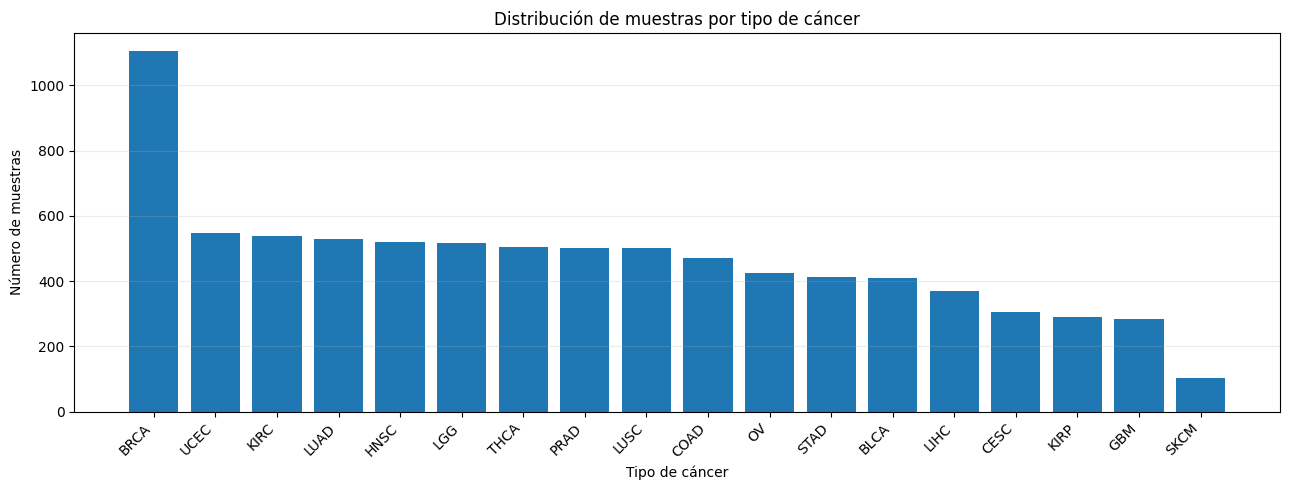

Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/app_02_porcentaje_clases.png


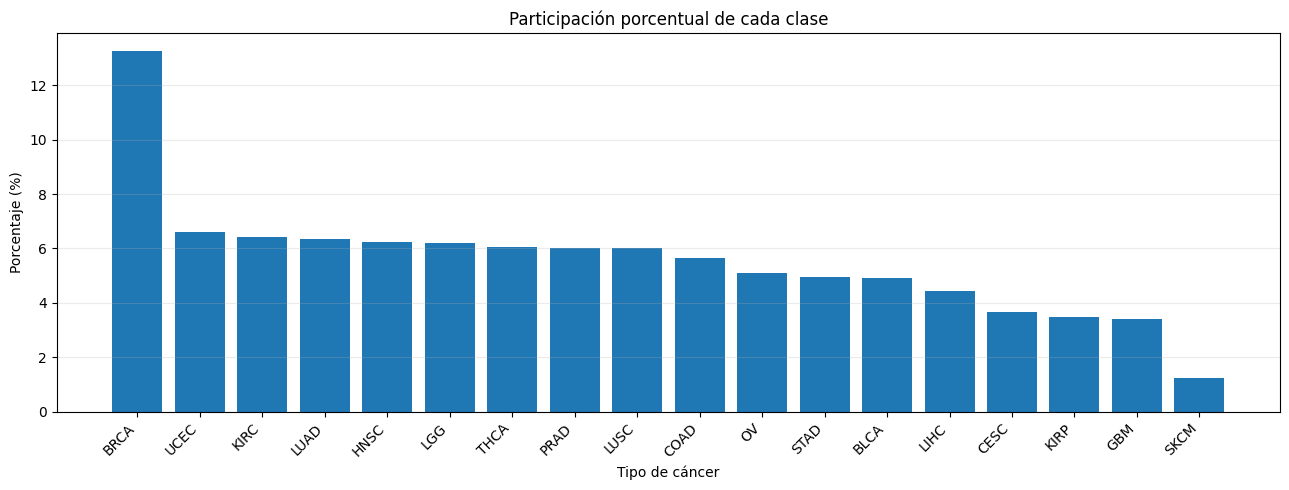

In [6]:
pdf_clases = df_clases.toPandas().sort_values("n_muestras", ascending=False)
mostrar(df_clases.orderBy(F.desc("n_muestras")), 30)

plt.figure(figsize=(13,5))
plt.bar(pdf_clases["cancer_type"], pdf_clases["n_muestras"])
plt.title("Distribución de muestras por tipo de cáncer")
plt.xlabel("Tipo de cáncer")
plt.ylabel("Número de muestras")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
guardar_figura("app_01_distribucion_clases.png")
plt.show()

pdf_desbalance = df_desbalance.toPandas().sort_values("n_muestras", ascending=False)
if "porcentaje" in pdf_desbalance.columns:
    plt.figure(figsize=(13,5))
    plt.bar(pdf_desbalance["cancer_type"], pdf_desbalance["porcentaje"])
    plt.title("Participación porcentual de cada clase")
    plt.xlabel("Tipo de cáncer")
    plt.ylabel("Porcentaje (%)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    guardar_figura("app_02_porcentaje_clases.png")
    plt.show()

,modelo,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro_ovr,pr_auc_macro_ovr,gap_f1_macro_train_validation,gap_accuracy_train_validation
0,SparkXGBClassifier,test,0.966587,0.963092,0.965833,0.963092,0.964060,0.967128,0.966587,0.966476,0.998921,0.989523,0.023037,0.020000
1,OneVsRest_LinearSVC,test,0.965792,0.962190,0.964096,0.962190,0.962655,0.966450,0.965792,0.965700,NaN,NaN,0.008082,0.007526
2,LogisticRegression_multinomial,test,0.963405,0.960950,0.958997,0.960950,0.959628,0.964131,0.963405,0.963489,0.999094,0.987619,0.011647,0.010153
3,SparkXGBClassifier,train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.023037,0.020000
4,OneVsRest_LinearSVC,train,0.981126,0.979164,0.979528,0.979164,0.979268,0.981149,0.981126,0.981062,NaN,NaN,0.008082,0.007526
5,LogisticRegression_multinomial,train,0.979753,0.979348,0.977462,0.979348,0.978339,0.979880,0.979753,0.979762,0.999739,0.995806,0.011647,0.010153
6,SparkXGBClassifier,validation,0.980000,0.979789,0.974905,0.979789,0.976963,0.980605,0.980000,0.980088,0.999366,0.992162,0.023037,0.020000
7,OneVsRest_LinearSVC,validation,0.973600,0.971300,0.971824,0.971300,0.971187,0.973832,0.973600,0.973399,NaN,NaN,0.008082,0.007526
8,LogisticRegression_multinomial,validation,0.969600,0.968007,0.965906,0.968007,0.966691,0.969772,0.969600,0.969468,0.999257,0.990770,0.011647,0.010153


Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/app_03_comparacion_modelos_f1_macro.png


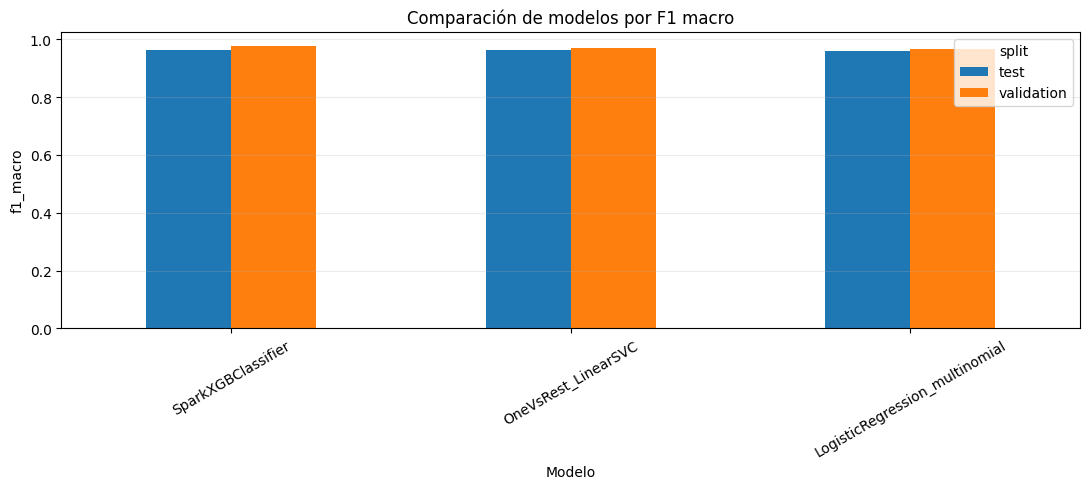

Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/app_04_comparacion_modelos_balanced_accuracy.png


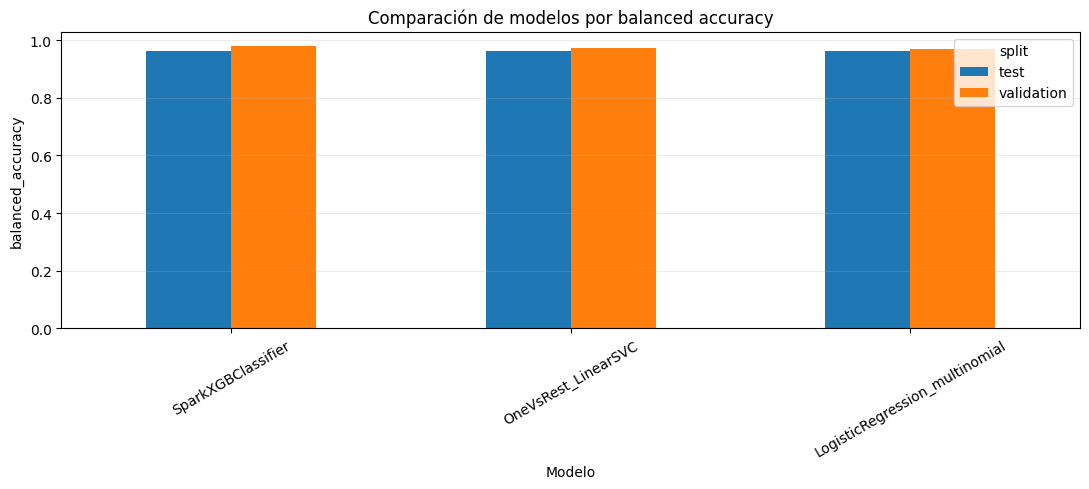

Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/app_05_comparacion_modelos_pr_auc_macro.png


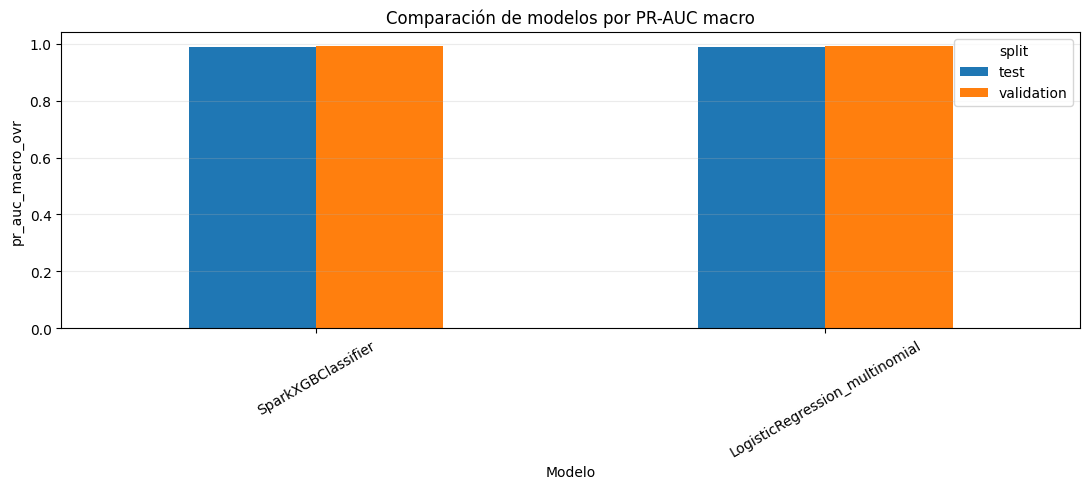

Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/app_06_comparacion_modelos_roc_auc_macro.png


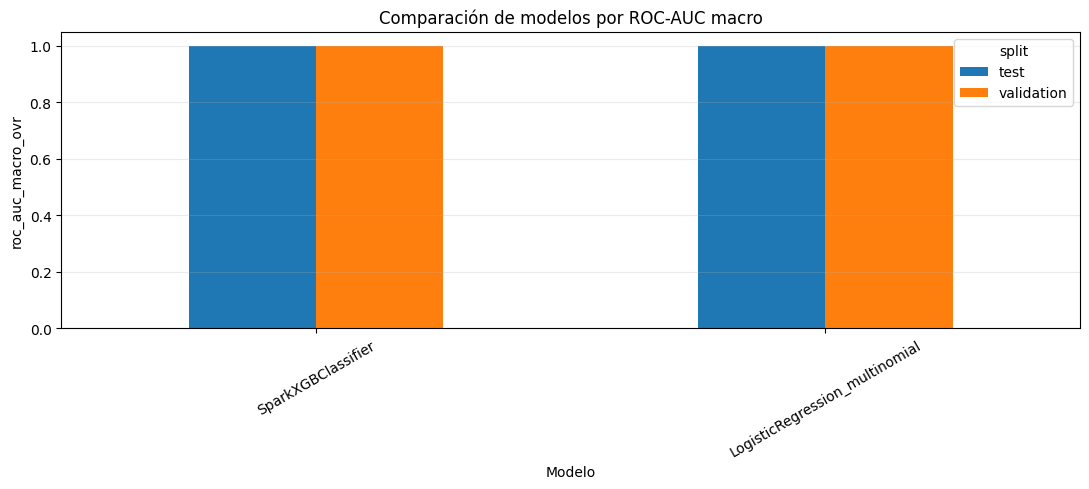

,modelo,parametro,valor
0,LogisticRegression_multinomial,elasticNetParam,0.0
1,LogisticRegression_multinomial,maxIter,80
2,LogisticRegression_multinomial,regParam,0.01
3,OneVsRest_LinearSVC,maxIter,50
4,OneVsRest_LinearSVC,regParam,0.01
5,SparkXGBClassifier,colsample_bytree,0.8
6,SparkXGBClassifier,gamma,0.0
7,SparkXGBClassifier,learning_rate,0.1
8,SparkXGBClassifier,max_depth,5
9,SparkXGBClassifier,min_child_weight,1


In [7]:
columnas_metricas = [c for c in [
    "modelo", "split", "accuracy", "balanced_accuracy", "precision_macro", "recall_macro", "f1_macro",
    "precision_weighted", "recall_weighted", "f1_weighted", "roc_auc_macro_ovr", "pr_auc_macro_ovr",
    "gap_f1_macro_train_validation", "gap_accuracy_train_validation"
] if c in df_metricas.columns]

tabla_metricas = df_metricas.select(*columnas_metricas).orderBy("split", F.desc("f1_macro"))
mostrar(tabla_metricas, 100)
pdf_metricas = tabla_metricas.toPandas()

def plot_metric(metric_col, title, filename):
    data = pdf_metricas[pdf_metricas["split"].isin(["validation", "test"])]
    if data.empty or metric_col not in data.columns:
        return
    pivot = data.pivot_table(index="modelo", columns="split", values=metric_col, aggfunc="first").sort_values(by="validation", ascending=False)
    ax = pivot.plot(kind="bar", figsize=(11,5), rot=30)
    ax.set_title(title)
    ax.set_xlabel("Modelo")
    ax.set_ylabel(metric_col)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    guardar_figura(filename)
    plt.show()

plot_metric("f1_macro", "Comparación de modelos por F1 macro", "app_03_comparacion_modelos_f1_macro.png")
plot_metric("balanced_accuracy", "Comparación de modelos por balanced accuracy", "app_04_comparacion_modelos_balanced_accuracy.png")
plot_metric("pr_auc_macro_ovr", "Comparación de modelos por PR-AUC macro", "app_05_comparacion_modelos_pr_auc_macro.png")
plot_metric("roc_auc_macro_ovr", "Comparación de modelos por ROC-AUC macro", "app_06_comparacion_modelos_roc_auc_macro.png")

if df_hiper is not None:
    mostrar(df_hiper.orderBy("modelo", "parametro"), 100)

,clase,precision,recall,f1-score,support
4,PRAD,1.000000,1.000000,1.000000,75.0
18,SKCM,1.000000,1.000000,1.000000,16.0
6,LGG,1.000000,1.000000,1.000000,78.0
3,THCA,1.000000,0.986842,0.993377,76.0
16,COAD,0.986486,1.000000,0.993197,73.0
12,LIHC,0.982456,1.000000,0.991150,56.0
13,BRCA,0.993902,0.981928,0.987879,166.0
19,OV,0.984127,0.968750,0.976378,64.0
20,STAD,0.968254,0.983871,0.976000,62.0
7,KIRC,0.963415,0.975309,0.969325,81.0


Tabla local guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/tables/refined_app_desempeno_por_clase
Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/app_07_f1_por_clase_test.png


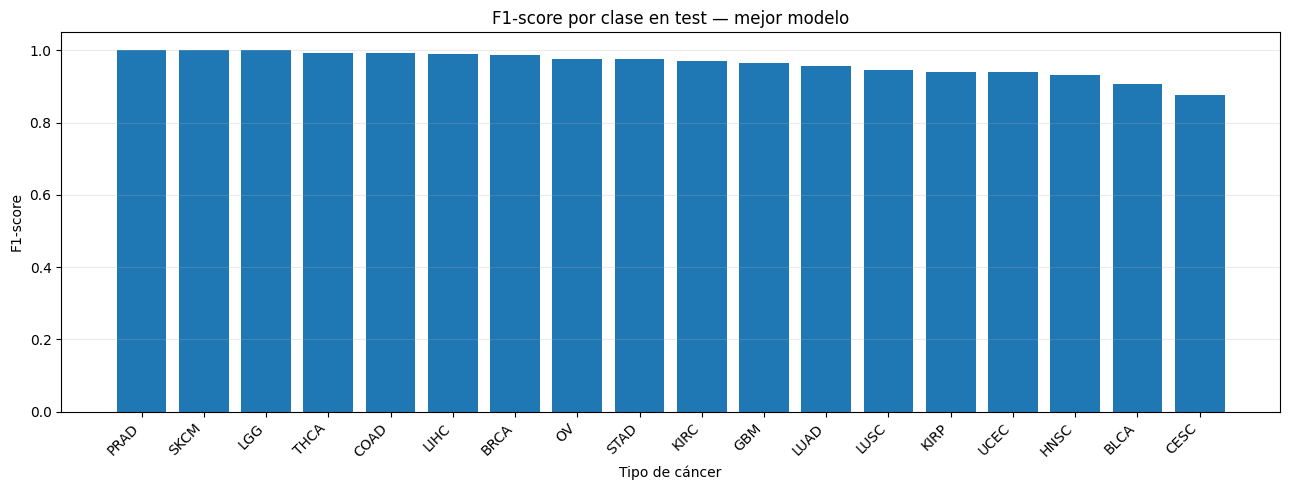

In [8]:
pdf_reporte = df_reporte.toPandas().copy()
filas_agregadas = {"accuracy", "macro avg", "weighted avg"}
pdf_reporte_clases = pdf_reporte[~pdf_reporte["clase"].isin(filas_agregadas)].copy() if "clase" in pdf_reporte.columns else pdf_reporte.copy()

for col in ["precision", "recall", "f1-score", "support"]:
    if col in pdf_reporte_clases.columns:
        pdf_reporte_clases[col] = pd.to_numeric(pdf_reporte_clases[col], errors="coerce")

if "f1-score" in pdf_reporte_clases.columns:
    pdf_reporte_clases = pdf_reporte_clases.sort_values("f1-score", ascending=False)

display(pdf_reporte_clases)
save_spark_table(spark.createDataFrame(pdf_reporte_clases), "refined_app_desempeno_por_clase")

if {"clase", "f1-score"}.issubset(pdf_reporte_clases.columns):
    plt.figure(figsize=(13,5))
    plt.bar(pdf_reporte_clases["clase"], pdf_reporte_clases["f1-score"])
    plt.title("F1-score por clase en test — mejor modelo")
    plt.xlabel("Tipo de cáncer")
    plt.ylabel("F1-score")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1.05)
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    guardar_figura("app_07_f1_por_clase_test.png")
    plt.show()

predicted_class,BLCA,BRCA,CESC,COAD,GBM,HNSC,KIRC,KIRP,LGG,LIHC,LUAD,LUSC,OV,PRAD,SKCM,STAD,THCA,UCEC
true_class,,,,,,,,,,,,,,,,,,
BLCA,54,0,3,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0
BRCA,1,163,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0
CESC,1,0,39,0,0,0,0,0,0,0,1,0,1,0,0,0,0,4
COAD,0,0,0,73,0,0,0,0,0,0,0,0,0,0,0,0,0,0
GBM,0,0,0,0,42,0,0,0,0,0,1,0,0,0,0,0,0,0
HNSC,0,1,0,0,0,75,0,0,0,0,0,1,0,0,0,0,0,1
KIRC,1,0,0,0,0,0,79,1,0,0,0,0,0,0,0,0,0,0
KIRP,1,0,0,0,0,0,3,40,0,0,0,0,0,0,0,0,0,0
LGG,0,0,0,0,0,0,0,0,78,0,0,0,0,0,0,0,0,0


Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/app_09_matriz_confusion_absoluta.png


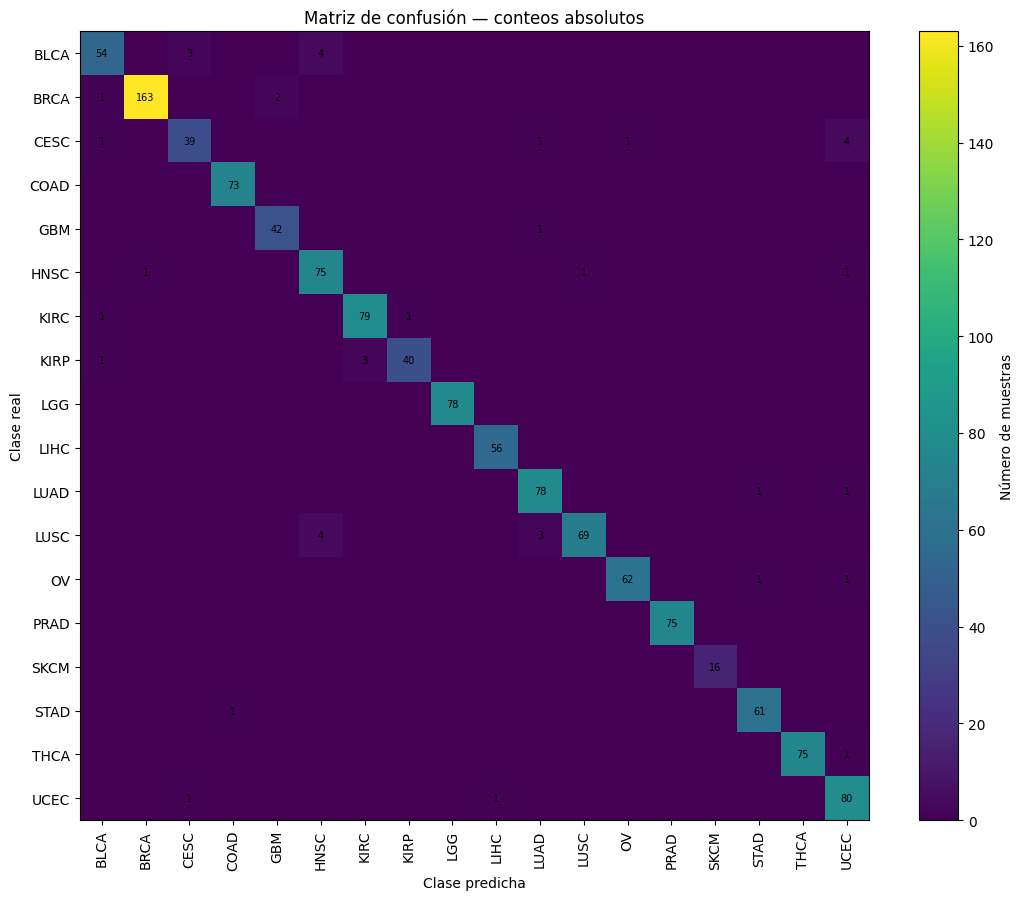

Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/app_10_matriz_confusion_normalizada.png


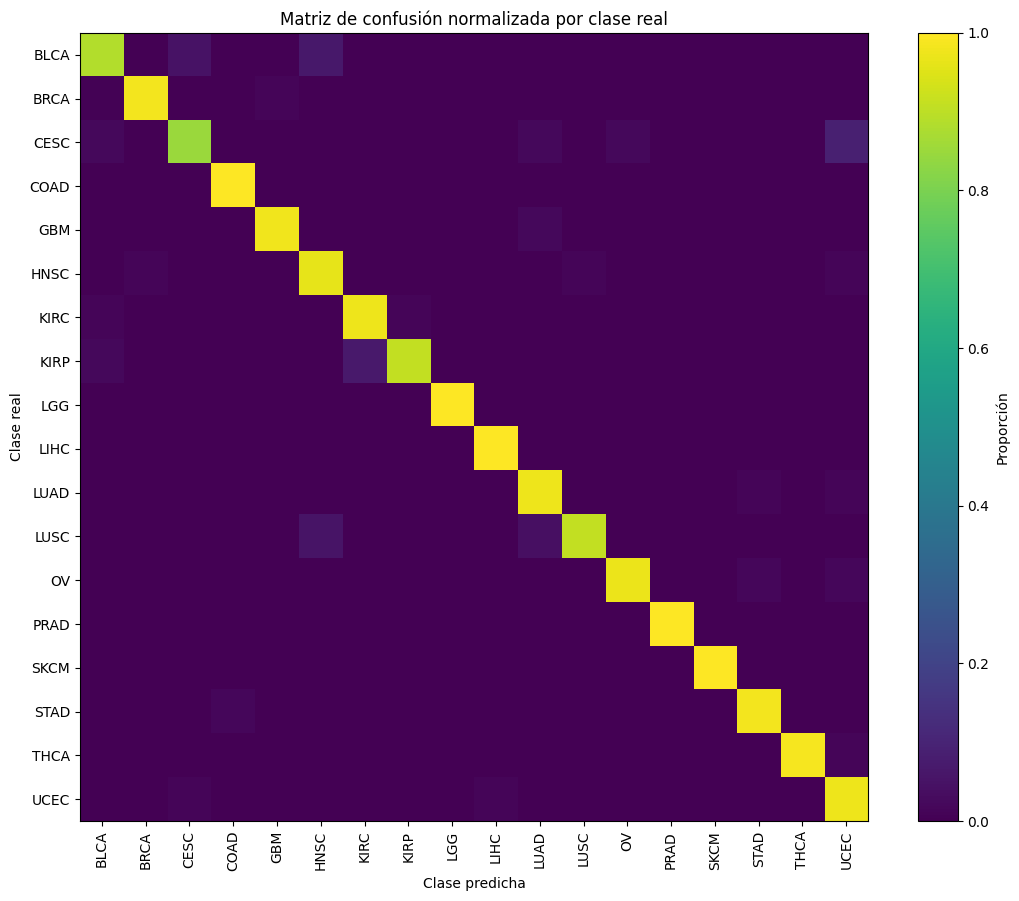

In [9]:
pdf_confusion = df_confusion.toPandas()
tabla_confusion = pdf_confusion.pivot_table(index="true_class", columns="predicted_class", values="n", aggfunc="sum", fill_value=0)
clases = list(tabla_confusion.index)
tabla_confusion = tabla_confusion.reindex(index=clases, columns=clases, fill_value=0)
display(tabla_confusion)

plt.figure(figsize=(11,9))
plt.imshow(tabla_confusion.values, interpolation="nearest")
plt.title("Matriz de confusión — conteos absolutos")
plt.colorbar(label="Número de muestras")
plt.xticks(np.arange(len(tabla_confusion.columns)), tabla_confusion.columns, rotation=90)
plt.yticks(np.arange(len(tabla_confusion.index)), tabla_confusion.index)
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
for i in range(tabla_confusion.shape[0]):
    for j in range(tabla_confusion.shape[1]):
        v = int(tabla_confusion.iloc[i, j])
        if v > 0:
            plt.text(j, i, str(v), ha="center", va="center", fontsize=7)
plt.tight_layout()
guardar_figura("app_09_matriz_confusion_absoluta.png")
plt.show()

tabla_norm = tabla_confusion.div(tabla_confusion.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
plt.figure(figsize=(11,9))
plt.imshow(tabla_norm.values, interpolation="nearest", vmin=0, vmax=1)
plt.title("Matriz de confusión normalizada por clase real")
plt.colorbar(label="Proporción")
plt.xticks(np.arange(len(tabla_norm.columns)), tabla_norm.columns, rotation=90)
plt.yticks(np.arange(len(tabla_norm.index)), tabla_norm.index)
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
guardar_figura("app_10_matriz_confusion_normalizada.png")
plt.show()

,cancer_type,cancer_predicho,n_errores
0,BLCA,HNSC,4
1,LUSC,HNSC,4
2,CESC,UCEC,4
3,LUSC,LUAD,3
4,BLCA,CESC,3
5,KIRP,KIRC,3
6,BRCA,GBM,2
7,UCEC,LIHC,1
8,THCA,UCEC,1
9,OV,STAD,1


Tabla local guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/tables/refined_app_errores_frecuentes
Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/app_11_top_errores_frecuentes.png


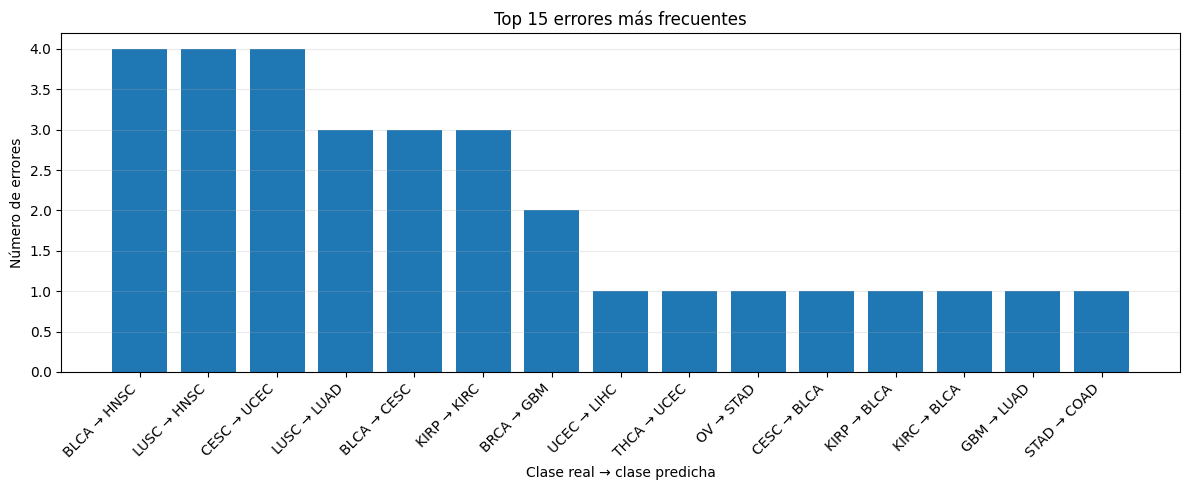

,cancer_type,n_test,n_aciertos,accuracy_por_clase
0,CESC,46,39,0.8478
1,BLCA,61,54,0.8852
2,LUSC,76,69,0.9079
3,KIRP,44,40,0.9091
4,HNSC,78,75,0.9615
5,OV,64,62,0.9688
6,LUAD,80,78,0.9750
7,KIRC,81,79,0.9753
8,UCEC,82,80,0.9756
9,GBM,43,42,0.9767


Tabla local guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/tables/refined_app_auditoria_predicciones


PosixPath('/Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/tables/refined_app_auditoria_predicciones')

In [10]:
errores = (
    df_pred
    .withColumn("es_error", F.when(F.col("cancer_type") != F.col("cancer_predicho"), F.lit(1)).otherwise(F.lit(0)))
    .filter(F.col("es_error") == 1)
    .groupBy("cancer_type", "cancer_predicho")
    .agg(F.count("*").alias("n_errores"))
    .orderBy(F.desc("n_errores"))
)
mostrar(errores, 50)
save_spark_table(errores, "refined_app_errores_frecuentes")

pdf_errores = errores.limit(15).toPandas()
if not pdf_errores.empty:
    pdf_errores["par_error"] = pdf_errores["cancer_type"] + " → " + pdf_errores["cancer_predicho"]
    plt.figure(figsize=(12,5))
    plt.bar(pdf_errores["par_error"], pdf_errores["n_errores"])
    plt.title("Top 15 errores más frecuentes")
    plt.xlabel("Clase real → clase predicha")
    plt.ylabel("Número de errores")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    guardar_figura("app_11_top_errores_frecuentes.png")
    plt.show()

auditoria = (
    df_pred
    .withColumn("acierto", F.when(F.col("cancer_type") == F.col("cancer_predicho"), F.lit(1)).otherwise(F.lit(0)))
    .groupBy("cancer_type")
    .agg(F.count("*").alias("n_test"), F.sum("acierto").alias("n_aciertos"), F.round(F.avg("acierto"), 4).alias("accuracy_por_clase"))
    .orderBy(F.asc("accuracy_por_clase"), F.desc("n_test"))
)
mostrar(auditoria, 30)
save_spark_table(auditoria, "refined_app_auditoria_predicciones")

,gene,importance
0,ENSG00000162728,0.054766
1,ENSG00000070019,0.048614
2,ENSG00000167117,0.045668
3,ENSG00000167751,0.043885
4,ENSG00000163202,0.039696
5,ENSG00000167772,0.033652
6,ENSG00000142515,0.030134
7,ENSG00000104447,0.029836
8,ENSG00000080910,0.029302
9,ENSG00000152804,0.028640


Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/app_13_top20_genes_importancia_rfe.png


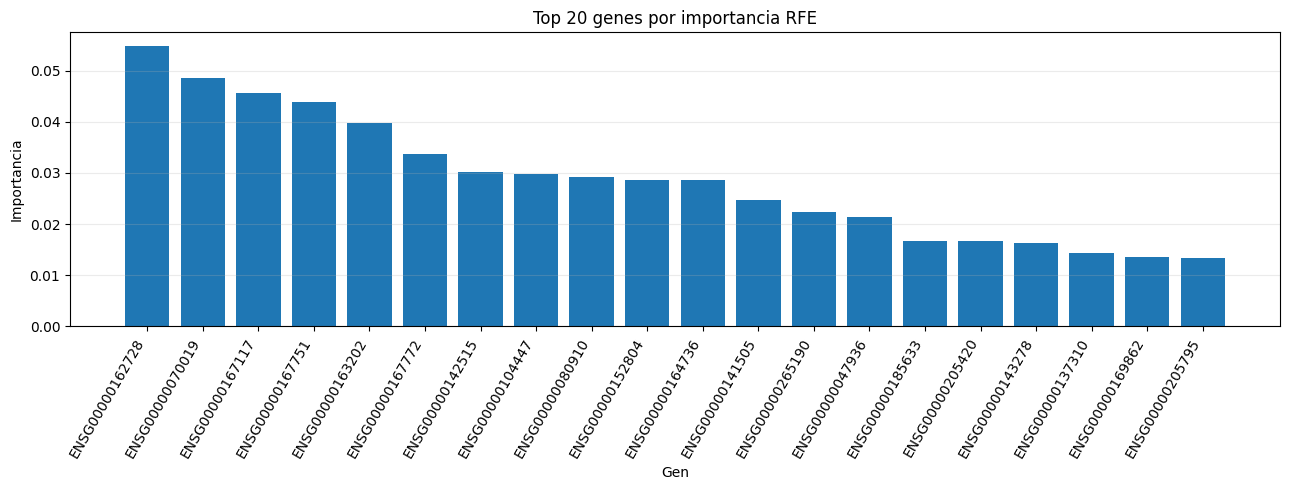

Figura guardada: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations/app_15_expresion_promedio_por_clase.png


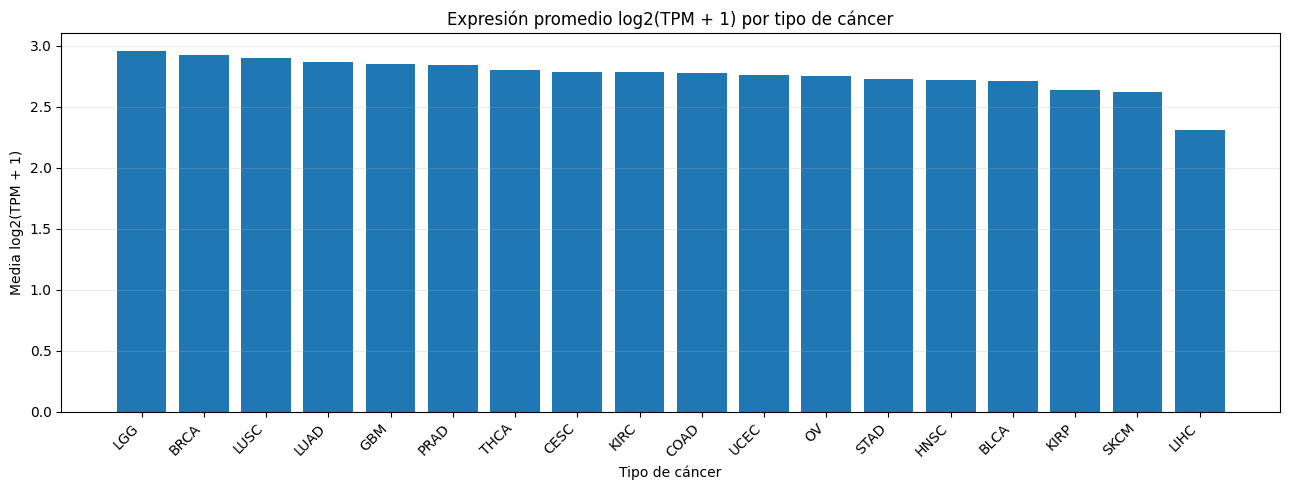

In [11]:
if df_importancias_rfe is not None:
    pdf_imp = df_importancias_rfe.orderBy(F.desc("importance")).limit(20).toPandas()
    display(pdf_imp)
    gene_col = "gene" if "gene" in pdf_imp.columns else "gene_id_base"
    plt.figure(figsize=(13,5))
    plt.bar(pdf_imp[gene_col], pdf_imp["importance"])
    plt.title("Top 20 genes por importancia RFE")
    plt.xlabel("Gen")
    plt.ylabel("Importancia")
    plt.xticks(rotation=60, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    guardar_figura("app_13_top20_genes_importancia_rfe.png")
    plt.show()

if df_expr is not None:
    pdf_expr = df_expr.toPandas().sort_values("media_log2_tpm", ascending=False)
    plt.figure(figsize=(13,5))
    plt.bar(pdf_expr["cancer_type"], pdf_expr["media_log2_tpm"])
    plt.title("Expresión promedio log2(TPM + 1) por tipo de cáncer")
    plt.xlabel("Tipo de cáncer")
    plt.ylabel("Media log2(TPM + 1)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    guardar_figura("app_15_expresion_promedio_por_clase.png")
    plt.show()

In [12]:
# Exportación final a CSV
tabla_metricas.toPandas().to_csv(REFINED_VISUALIZATIONS_PATH / "app_tabla_metricas_informe.csv", index=False)
resumen.to_csv(REFINED_VISUALIZATIONS_PATH / "app_resumen_ejecutivo.csv", index=False)
pdf_reporte_clases.to_csv(REFINED_VISUALIZATIONS_PATH / "app_desempeno_por_clase.csv", index=False)
errores.toPandas().to_csv(REFINED_VISUALIZATIONS_PATH / "app_errores_frecuentes.csv", index=False)
auditoria.toPandas().to_csv(REFINED_VISUALIZATIONS_PATH / "app_auditoria_predicciones.csv", index=False)

print("CSV exportados en:", REFINED_VISUALIZATIONS_PATH)

CSV exportados en: /Users/momos/Downloads/notebooks_locales_tcga/data_local/refined/visualizations
